<a href="https://colab.research.google.com/github/p22030124069-boop/SIMULASI-ECG-2026/blob/main/Simulasi_ECG_Sarjis_Resh_Aina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

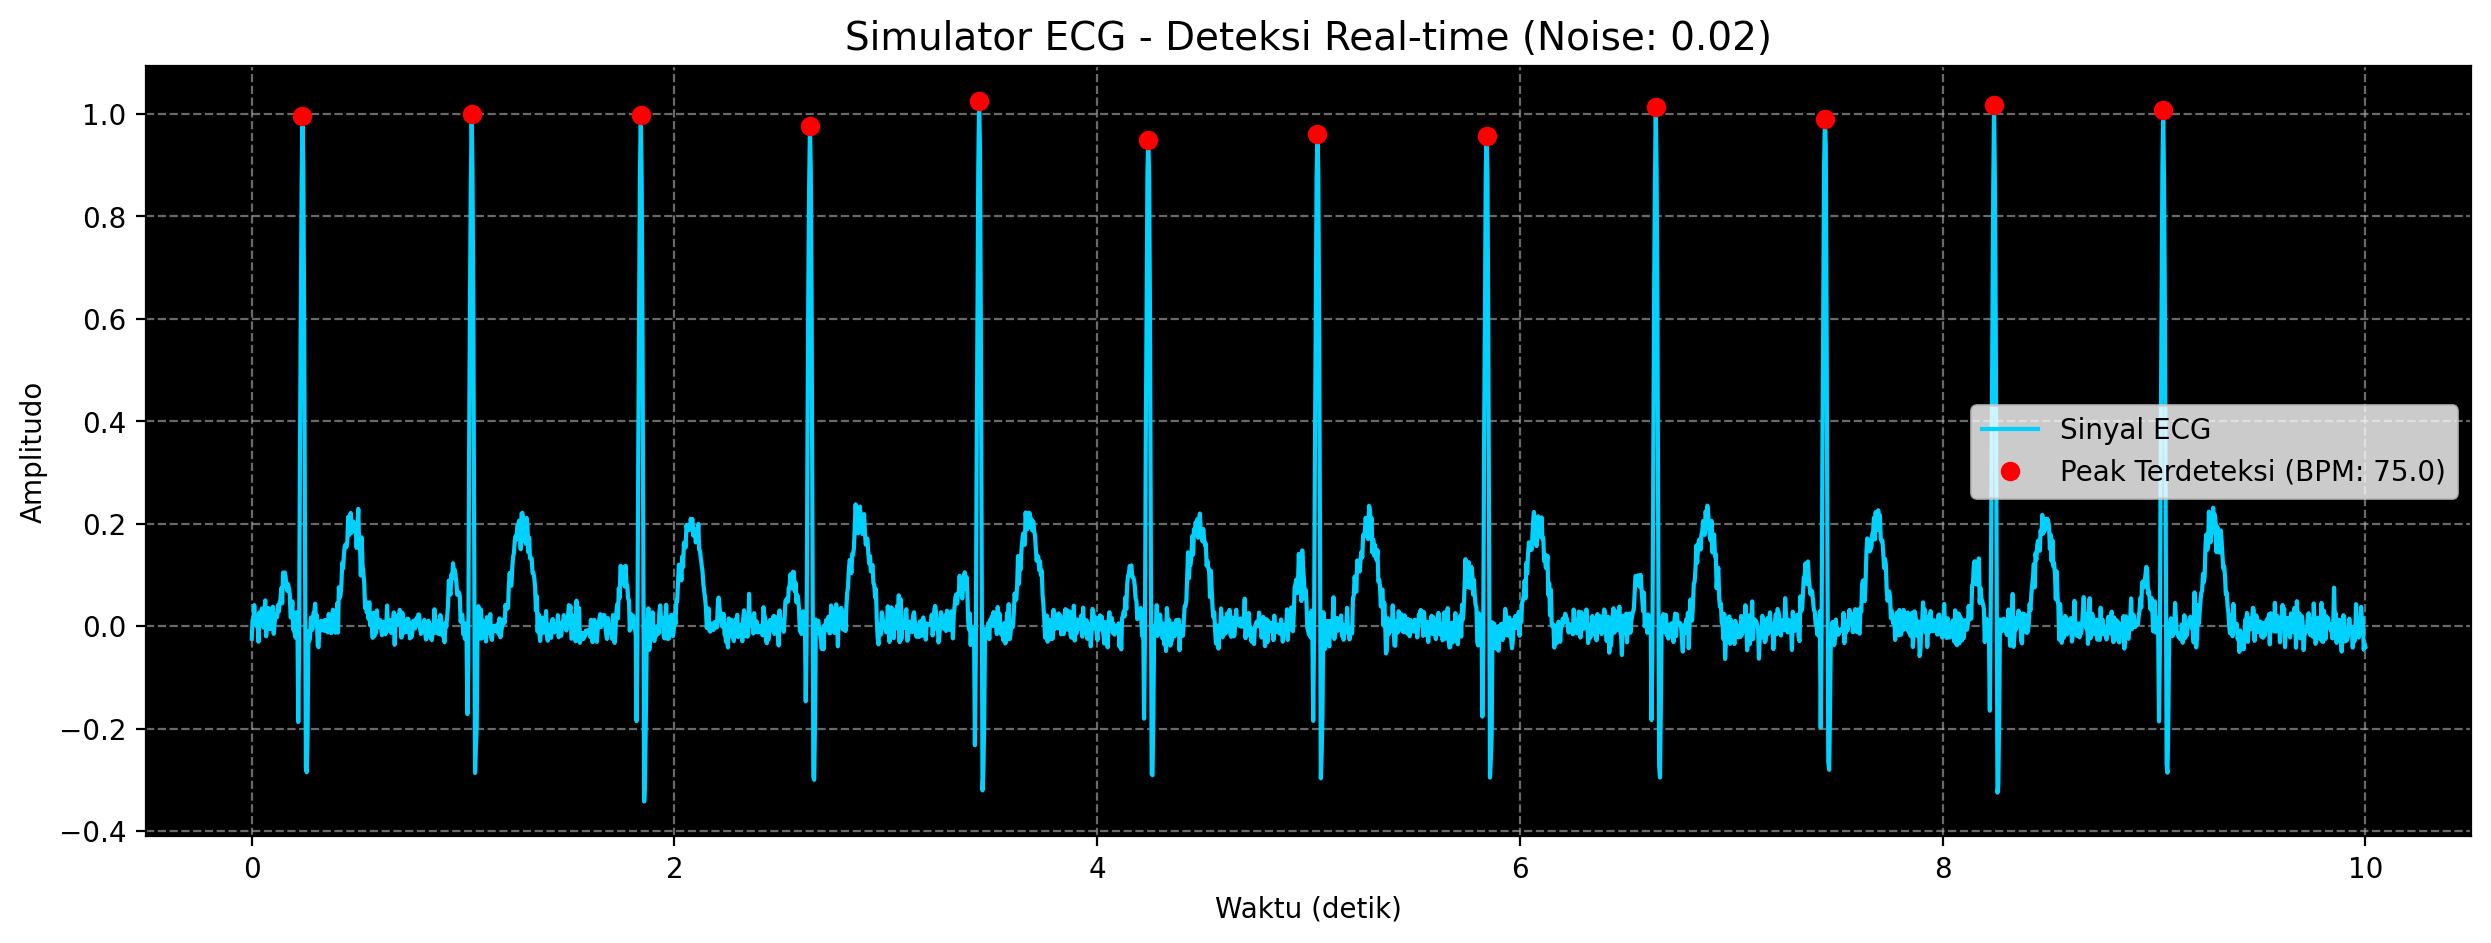

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import Audio, display

# Agar grafik terlihat tajam dan berwarna di Colab
%config InlineBackend.figure_format = 'retina'
def generate_ecg(duration=10, fs=500, bpm=60, noise_level=0.05):
    """
    duration: durasi dalam detik
    fs: sampling rate (Hz)
    bpm: detak jantung per menit
    noise_level: intensitas gangguan (0.0 - 1.0)
    """
    t = np.linspace(0, duration, duration * fs)
    heart_rate_hz = bpm / 60

    ecg_signal = np.zeros_like(t)

    # Generate a more realistic ECG waveform including PQRST
    period = 1 / heart_rate_hz
    beats = int(duration / period)

    for i in range(beats):
        start_time = i * period
        end_time = (i + 1) * period

        # Create a local time axis for one beat
        t_beat = np.linspace(0, period, int(period * fs), endpoint=False)

        # Initialize wave components
        p_wave = np.zeros_like(t_beat)
        q_wave = np.zeros_like(t_beat)
        r_wave = np.zeros_like(t_beat)
        s_wave = np.zeros_like(t_beat)
        t_wave = np.zeros_like(t_beat)

        # P-wave (at ~0.15 * period, duration ~0.1 * period)
        p_start = int(0.15 * period * fs)
        p_duration = int(0.1 * period * fs)
        p_end = p_start + p_duration
        if p_end < len(t_beat):
            p_wave[p_start:p_end] = 0.1 * np.sin(np.pi * np.linspace(0, 1, p_duration))

        # QRS complex (R-peak at ~0.3 * period)
        r_peak_time_index = int(0.3 * period * fs)

        # R-wave (sharp peak)
        r_duration = int(0.04 * period * fs) # very short
        r_start = r_peak_time_index - int(r_duration/2)
        r_end = r_start + r_duration
        if r_start >= 0 and r_end < len(t_beat):
            r_wave[r_start:r_end] = 1.0 * np.exp(-((t_beat[r_start:r_end] - t_beat[r_peak_time_index])**2) / (2 * (0.01 * period)**2))

        # Q-wave (small downward before R)
        q_duration = int(0.02 * period * fs)
        q_start = r_peak_time_index - q_duration - int(0.01 * period * fs)
        q_end = r_peak_time_index - int(0.01 * period * fs)
        if q_start >= 0 and q_end < len(t_beat):
            q_wave[q_start:q_end] = -0.2 * np.sin(np.pi * np.linspace(0, 1, q_end - q_start))

        # S-wave (small downward after R)
        s_duration = int(0.03 * period * fs)
        s_start = r_peak_time_index + int(0.01 * period * fs)
        s_end = s_start + s_duration
        if s_start >= 0 and s_end < len(t_beat):
            s_wave[s_start:s_end] = -0.3 * np.sin(np.pi * np.linspace(0, 1, s_duration))

        # T-wave (at ~0.5 * period, duration ~0.2 * period)
        t_start = int(0.5 * period * fs)
        t_duration = int(0.2 * period * fs)
        t_end = t_start + t_duration
        if t_start >= 0 and t_end < len(t_beat):
            t_wave[t_start:t_end] = 0.2 * np.sin(np.pi * np.linspace(0, 1, t_duration))

        # Combine waves for one beat
        beat_waveform = p_wave + q_wave + r_wave + s_wave + t_wave

        # Place the beat waveform into the main signal
        segment_start_idx = int(start_time * fs)
        segment_end_idx = min(int(end_time * fs), len(ecg_signal))

        # Ensure the beat_waveform matches the length of the segment
        if len(beat_waveform) > (segment_end_idx - segment_start_idx):
            beat_waveform = beat_waveform[:(segment_end_idx - segment_start_idx)]
        elif len(beat_waveform) < (segment_end_idx - segment_start_idx):
            # Pad with zeros if necessary (shouldn't happen with correct fs and period calculation)
            beat_waveform = np.pad(beat_waveform, (0, (segment_end_idx - segment_start_idx) - len(beat_waveform)), 'constant')

        ecg_signal[segment_start_idx:segment_end_idx] += beat_waveform

    # Menambahkan noise (gangguan)
    noise = np.random.normal(0, noise_level, len(t))
    ecg_signal_noisy = ecg_signal + noise
    return t, ecg_signal_noisy
def process_ecg(t, signal, fs):
    # Mencari puncak (height disesuaikan dengan skala sinyal)
    # Adjust height to detect R-peaks more robustly
    # Increased height threshold to be more selective for R-peaks.
    # Increased distance to prevent detection of P or T waves as separate peaks within one beat.
    # A distance of fs * 0.6 ensures peaks are separated by at least 60% of a second (for fs=250, this is 150 samples),
    # which is likely more than the duration of any non-R wave feature within a single beat.
    peaks, _ = find_peaks(signal, height=0.9 * np.max(signal), distance=int(fs * 0.7))

    # Menghitung BPM berdasarkan jarak antar puncak (RR-interval)
    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / fs
        actual_bpm = 60 / np.mean(rr_intervals)
    else:
        actual_bpm = 0

    return peaks, actual_bpm
    # --- PARAMETER YANG BISA KAMU GANTI ---
DURASI = 10          # detik
FS = 250      # sampling rate
TARGET_BPM = 75   # detak yang diinginkan
NOISE = 0.02        # ganti angka ini (misal 0.01 sampai 0.5)
# --------------------------------------

# 1. Generate
t, signal = generate_ecg(DURASI, FS, TARGET_BPM, NOISE)

# 2 & 3. Deteksi Peak & Hitung BPM
peaks, real_bpm = process_ecg(t, signal, FS)

# 4. Plotting Berwarna
plt.figure(figsize=(15, 5))
plt.plot(t, signal, color='#00d1ff', label='Sinyal ECG', linewidth=1.5) # Warna Cyan
plt.plot(t[peaks], signal[peaks], "ro", label=f'Peak Terdeteksi (BPM: {real_bpm:.1f})') # Titik Merah

plt.title(f"Simulator ECG - Deteksi Real-time (Noise: {NOISE})", fontsize=14)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.gca().set_facecolor('black') # Setting facecolor for the axes
plt.show()

# --- MUNCULKAN BUNYI ---
# Membuat suara beep pendek setiap kali ada detak
def play_beep(bpm, duration):
    f_beep = 1000 # Frekuensi beep 1000Hz
    # The beep signal should be generated for the full duration of the ECG signal
    # not just a short t_beep interval, to align with the peaks.

    # Ensure FS is used consistently for audio generation

    beep_signal_output = np.zeros_like(signal) # Use the same length as the generated ECG signal
    for p in peaks:
        # Generate a short sine wave for each beep
        beep_duration = 0.05 # seconds
        beep_len = int(beep_duration * FS)
        beep_time = np.linspace(0, beep_duration, beep_len, endpoint=False)
        single_beep = 0.5 * np.sin(2 * np.pi * f_beep * beep_time)

        # Place the beep at the peak location
        start_idx = p - int(beep_len / 2) # Center the beep around the peak
        end_idx = start_idx + beep_len

        # Ensure indices are within bounds
        if start_idx < 0:
            start_idx = 0
        if end_idx > len(beep_signal_output):
            end_idx = len(beep_signal_output)
            start_idx = end_idx - beep_len

        beep_signal_output[start_idx:end_idx] += single_beep

    display(Audio(beep_signal_output, rate=FS, autoplay=True))

play_beep(real_bpm, DURASI)

### Understanding and Adjusting PQRST Wave Parameters

The `generate_ecg` function constructs the ECG waveform by superimposing individual P, Q, R, S, and T waves within each heart beat cycle. Each wave has several parameters that you can modify to change its appearance:

*   **`period`**: This is the duration of one heart beat cycle, derived from `bpm` and `fs`. All wave timings (`_start`, `_duration`) are relative to this `period`.

#### P-Wave
*   **`p_start`**: Controls when the P-wave begins within the beat cycle. (e.g., `0.15 * period * fs` means 15% into the beat cycle).
*   **`p_duration`**: Controls how long the P-wave lasts. (e.g., `0.1 * period * fs` means 10% of the beat cycle duration).
*   **Amplitude**: The `0.1` multiplier before `np.sin` controls its height.

#### QRS Complex
*   **`r_peak_time_index`**: Defines the central point of the R-peak within the beat cycle (e.g., `0.3 * period * fs`).
*   **R-Wave**:
    *   **`r_duration`**: Very short duration for the sharp R-wave.
    *   **Amplitude**: The `1.0` multiplier controls the R-wave's height.
    *   **Gaussian Width**: The `(0.01 * period)**2` in the `np.exp` function determines the sharpness/width of the R-peak.
*   **Q-Wave**:
    *   **`q_duration`**: Duration of the downward Q-wave.
    *   **Amplitude**: The `-0.2` multiplier controls its depth.
    *   **`q_start` / `q_end`**: Calculated relative to `r_peak_time_index` to position it just before the R-wave.
*   **S-Wave**:
    *   **`s_duration`**: Duration of the downward S-wave.
    *   **Amplitude**: The `-0.3` multiplier controls its depth.
    *   **`s_start` / `s_end`**: Calculated relative to `r_peak_time_index` to position it just after the R-wave.

#### T-Wave
*   **`t_start`**: Controls when the T-wave begins (e.g., `0.5 * period * fs`).
*   **`t_duration`**: Controls how long the T-wave lasts (e.g., `0.2 * period * fs`).
*   **Amplitude**: The `0.2` multiplier controls its height.


### How to Modify for More Realistic Shapes:

1.  **Timing (`_start`, `_end` / `_duration`)**: These are relative to the `period`. A value like `0.15 * period` means 15% through the current heart beat cycle. Adjust these percentages to shift when a wave appears or how long it lasts.
2.  **Amplitude**: The numeric multipliers (e.g., `0.1` for P-wave, `1.0` for R-wave, `-0.2` for Q-wave) directly control the vertical scale of each wave. Increase for taller/deeper waves, decrease for flatter ones.
3.  **Shape Specifics**: For R-wave, the Gaussian `exp` function determines its sharp peak. Adjusting the `(0.01 * period)**2` term will make it wider or narrower. For P, Q, S, T waves, they use `np.sin` functions, so their general shape is fixed, but their duration and amplitude give some flexibility.

It's an iterative process. You'll need to experiment with these values and observe the plot to achieve the desired PQRST morphology.

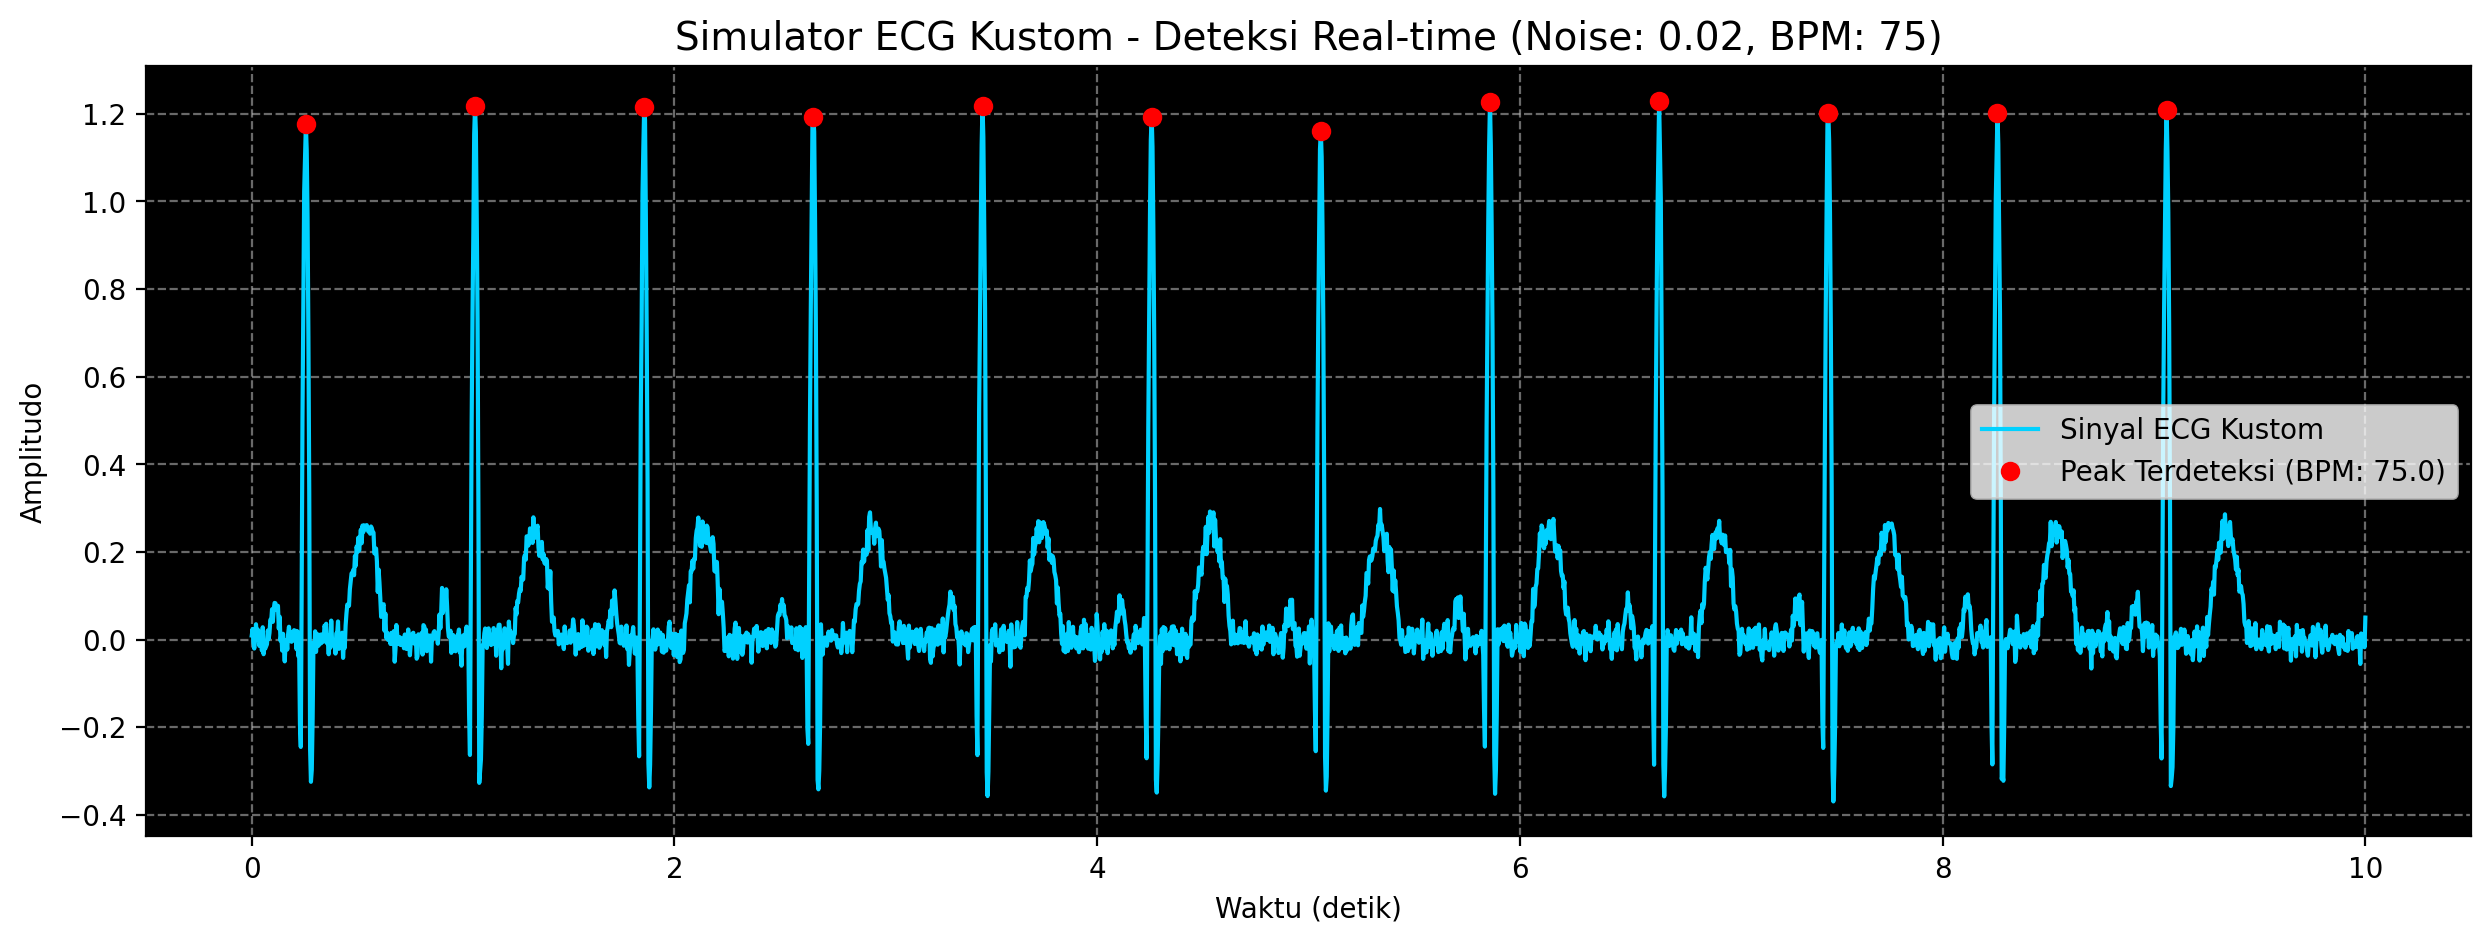

In [19]:
# --- PARAMETER YANG BISA KAMU GANTI UNTUK GELOMBANG PQRST ---

# Ini adalah contoh bagaimana kamu bisa mengatur ulang nilai-nilai dalam fungsi generate_ecg
# untuk mendapatkan bentuk PQRST yang berbeda.
# Kamu bisa langsung mengedit fungsi generate_ecg di sel sebelumnya,
# atau menyalinnya ke sini dan memodifikasinya.

def generate_custom_ecg(duration=10, fs=500, bpm=60, noise_level=0.05):
    t = np.linspace(0, duration, duration * fs)
    heart_rate_hz = bpm / 60
    ecg_signal = np.zeros_like(t)
    period = 1 / heart_rate_hz
    beats = int(duration / period)

    for i in range(beats):
        start_time = i * period

        t_beat = np.linspace(0, period, int(period * fs), endpoint=False)
        p_wave = np.zeros_like(t_beat)
        q_wave = np.zeros_like(t_beat)
        r_wave = np.zeros_like(t_beat)
        s_wave = np.zeros_like(t_beat)
        t_wave = np.zeros_like(t_beat)

        # --- CUSTOMISASI PARAMETER GELOMBANG PQRST DI SINI ---

        # P-Wave
        # Lebih awal, durasi sedikit lebih pendek, amplitudo lebih rendah
        p_start_rel = 0.10 # Mulai 10% dari siklus
        p_duration_rel = 0.08 # Durasi 8% dari siklus
        p_amplitude = 0.08 # Amplitudo lebih kecil

        p_start = int(p_start_rel * period * fs)
        p_duration = int(p_duration_rel * period * fs)
        p_end = p_start + p_duration
        if p_end < len(t_beat):
            p_wave[p_start:p_end] = p_amplitude * np.sin(np.pi * np.linspace(0, 1, p_duration))

        # QRS Complex
        r_peak_time_index_rel = 0.32 # R-peak sedikit lebih lambat
        r_peak_time_index = int(r_peak_time_index_rel * period * fs)

        # R-wave (Amplitudo lebih tinggi, sedikit lebih lebar)
        r_duration_rel = 0.05 # Durasi R sedikit lebih panjang
        r_amplitude = 1.2 # Amplitudo R lebih tinggi
        r_sharpness_factor = 0.015 # Membuat R-peak sedikit kurang tajam

        r_duration = int(r_duration_rel * period * fs)
        r_start = r_peak_time_index - int(r_duration/2)
        r_end = r_start + r_duration
        if r_start >= 0 and r_end < len(t_beat):
            r_wave[r_start:r_end] = r_amplitude * np.exp(-((t_beat[r_start:r_end] - t_beat[r_peak_time_index])**2) / (2 * (r_sharpness_factor * period)**2))

        # Q-wave (lebih dalam, durasi sedikit lebih panjang)
        q_duration_rel = 0.025 # Durasi Q sedikit lebih panjang
        q_amplitude = -0.25 # Q-wave lebih dalam
        q_offset_rel = 0.015 # Offset dari R-peak

        q_duration = int(q_duration_rel * period * fs)
        q_start = r_peak_time_index - q_duration - int(q_offset_rel * period * fs)
        q_end = r_peak_time_index - int(q_offset_rel * period * fs)
        if q_start >= 0 and q_end < len(t_beat):
            q_wave[q_start:q_end] = q_amplitude * np.sin(np.pi * np.linspace(0, 1, q_end - q_start))

        # S-wave (lebih dalam, durasi sedikit lebih panjang)
        s_duration_rel = 0.035 # Durasi S sedikit lebih panjang
        s_amplitude = -0.35 # S-wave lebih dalam
        s_offset_rel = 0.015 # Offset dari R-peak

        s_duration = int(s_duration_rel * period * fs)
        s_start = r_peak_time_index + int(s_offset_rel * period * fs)
        s_end = s_start + s_duration
        if s_start >= 0 and s_end < len(t_beat):
            s_wave[s_start:s_end] = s_amplitude * np.sin(np.pi * np.linspace(0, 1, s_duration))

        # T-wave (lebih lebar, amplitudo lebih tinggi)
        t_start_rel = 0.55 # T-wave mulai sedikit lebih lambat
        t_duration_rel = 0.25 # Durasi T lebih panjang
        t_amplitude = 0.25 # Amplitudo T lebih tinggi

        t_start = int(t_start_rel * period * fs)
        t_duration = int(t_duration_rel * period * fs)
        t_end = t_start + t_duration
        if t_start >= 0 and t_end < len(t_beat):
            t_wave[t_start:t_end] = t_amplitude * np.sin(np.pi * np.linspace(0, 1, t_duration))

        # --- AKHIR CUSTOMISASI ---

        beat_waveform = p_wave + q_wave + r_wave + s_wave + t_wave

        segment_start_idx = int(start_time * fs)
        segment_end_idx = min(int((start_time + period) * fs), len(ecg_signal))

        # Ensure beat_waveform length matches segment_end_idx - segment_start_idx
        current_segment_length = segment_end_idx - segment_start_idx
        if len(beat_waveform) > current_segment_length:
            beat_waveform = beat_waveform[:current_segment_length]
        elif len(beat_waveform) < current_segment_length:
            beat_waveform = np.pad(beat_waveform, (0, current_segment_length - len(beat_waveform)), 'constant')

        ecg_signal[segment_start_idx:segment_end_idx] += beat_waveform

    noise = np.random.normal(0, noise_level, len(t))
    ecg_signal_noisy = ecg_signal + noise
    return t, ecg_signal_noisy

# --- PARAMETER UTAMA YANG BISA KAMU GANTI --- (Untuk demonstrasi)
DURASI = 10          # detik
FS = 250            # sampling rate
TARGET_BPM = 75     # detak yang diinginkan (contoh: diubah)
NOISE = 0.02       # ganti angka ini (misal 0.01 sampai 0.5)
# --------------------------------------

# 1. Generate dengan fungsi custom
t_custom, signal_custom = generate_custom_ecg(DURASI, FS, TARGET_BPM, NOISE)

# 2 & 3. Deteksi Peak & Hitung BPM
peaks_custom, real_bpm_custom = process_ecg(t_custom, signal_custom, FS)

# 4. Plotting Berwarna
plt.figure(figsize=(15, 5))
plt.plot(t_custom, signal_custom, color='#00d1ff', label='Sinyal ECG Kustom', linewidth=1.5) # Warna Cyan
plt.plot(t_custom[peaks_custom], signal_custom[peaks_custom], "ro", label=f'Peak Terdeteksi (BPM: {real_bpm_custom:.1f})') # Titik Merah

plt.title(f"Simulator ECG Kustom - Deteksi Real-time (Noise: {NOISE}, BPM: {TARGET_BPM})", fontsize=14)
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.gca().set_facecolor('black') # Setting facecolor for the axes
plt.show()

# --- MUNCULKAN BUNYI --- (dengan fungsi play_beep yang sudah ada)
play_beep(real_bpm_custom, DURASI)